In [167]:
import pandas as pd
import numpy as np

In [168]:
df = pd.read_csv('../data/raw/data.csv')
print(df.shape)

(6819, 96)


In [169]:
df.describe()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,...,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.0,6819.000000
mean,0.032263,0.505180,0.558625,0.553589,0.607948,0.607929,0.998755,0.797190,0.809084,0.303623,...,0.807760,1.862942e+07,0.623915,0.607946,0.840402,0.280365,0.027541,0.565358,1.0,0.047578
std,0.176710,0.060686,0.065620,0.061595,0.016934,0.016916,0.013010,0.012869,0.013601,0.011163,...,0.040332,3.764501e+08,0.012290,0.016934,0.014523,0.014463,0.015668,0.013214,0.0,0.050014
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000
25%,0.000000,0.476527,0.535543,0.527277,0.600445,0.600434,0.998969,0.797386,0.809312,0.303466,...,0.796750,9.036205e-04,0.623636,0.600443,0.840115,0.276944,0.026791,0.565158,1.0,0.024477
50%,0.000000,0.502706,0.559802,0.552278,0.605997,0.605976,0.999022,0.797464,0.809375,0.303525,...,0.810619,2.085213e-03,0.623879,0.605998,0.841179,0.278778,0.026808,0.565252,1.0,0.033798
75%,0.000000,0.535563,0.589157,0.584105,0.613914,0.613842,0.999095,0.797579,0.809469,0.303585,...,0.826455,5.269777e-03,0.624168,0.613913,0.842357,0.281449,0.026913,0.565725,1.0,0.052838
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,9.820000e+09,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000


In [170]:
coltodrop =[]

In [171]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-tax net Int

In [172]:
df.isna().sum()

Bankrupt?                                                   0
 ROA(C) before interest and depreciation before interest    0
 ROA(A) before interest and % after tax                     0
 ROA(B) before interest and depreciation after tax          0
 Operating Gross Margin                                     0
                                                           ..
 Liability to Equity                                        0
 Degree of Financial Leverage (DFL)                         0
 Interest Coverage Ratio (Interest expense to EBIT)         0
 Net Income Flag                                            0
 Equity to Liability                                        0
Length: 96, dtype: int64

In [173]:
cols_with_na = df.columns[df.isna().sum() > 0]
print(cols_with_na)

Index([], dtype='object')


In [174]:
col_n = df.columns[df.nunique() <10]
print(col_n)
print(df[col_n].nunique())

Index(['Bankrupt?', ' Liability-Assets Flag', ' Net Income Flag'], dtype='object')
Bankrupt?                 2
 Liability-Assets Flag    2
 Net Income Flag          1
dtype: int64


In [175]:
flat_cols = []

for col in df.columns:
    top_ratio = df[col].value_counts(normalize=True, dropna=False).iloc[0]
    if top_ratio > 0.95:
        flat_cols.append(col)
        print(f"{col}: {top_ratio:.2f}")

print(flat_cols)

Bankrupt?: 0.97
 Liability-Assets Flag: 1.00
 Net Income Flag: 1.00
['Bankrupt?', ' Liability-Assets Flag', ' Net Income Flag']


In [176]:
coltodrop = []
coltodrop.append(" Liability-Assets Flag")
coltodrop.append(" Net Income Flag")

In [177]:
print(coltodrop)

[' Liability-Assets Flag', ' Net Income Flag']


In [178]:
df.shape

(6819, 96)

In [179]:
df = df.drop(columns = coltodrop)

In [180]:
df.shape

(6819, 94)

In [181]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 94 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-tax net Int

In [182]:
print(df.columns)

Index(['Bankrupt?', ' ROA(C) before interest and depreciation before interest',
       ' ROA(A) before interest and % after tax',
       ' ROA(B) before interest and depreciation after tax',
       ' Operating Gross Margin', ' Realized Sales Gross Margin',
       ' Operating Profit Rate', ' Pre-tax net Interest Rate',
       ' After-tax net Interest Rate',
       ' Non-industry income and expenditure/revenue',
       ' Continuous interest rate (after tax)', ' Operating Expense Rate',
       ' Research and development expense rate', ' Cash flow rate',
       ' Interest-bearing debt interest rate', ' Tax rate (A)',
       ' Net Value Per Share (B)', ' Net Value Per Share (A)',
       ' Net Value Per Share (C)', ' Persistent EPS in the Last Four Seasons',
       ' Cash Flow Per Share', ' Revenue Per Share (Yuan ¥)',
       ' Operating Profit Per Share (Yuan ¥)',
       ' Per Share Net profit before tax (Yuan ¥)',
       ' Realized Sales Gross Profit Growth Rate',
       ' Operating Profit

In [183]:
df.columns = [c.strip() for c in df.columns]

In [184]:
y = df["Bankrupt?"]
X = df.drop(columns = ["Bankrupt?"])

In [185]:
def safe_divide(a, b, eps=1e-6):
    return a / (np.abs(b) + eps)

def add_growth_and_financial_ratios(df):
    """
    Add growth features and financial impact ratios.
    Focus on debt service, profitability momentum, efficiency trends.
    """
    df = df.copy()
    eps = 1e-6
    
    # ===== GROWTH FEATURES (Rate of Change) =====
    # Profitability trend
    if "ROA(A) before interest and % after tax" in df.columns:
        roa = df["ROA(A) before interest and % after tax"]
        df["feat_roa_momentum"] = (roa - roa.shift(1)) / (roa.shift(1).abs() + eps)
        df["feat_roa_momentum"] = df["feat_roa_momentum"].fillna(0)
    
    # Leverage momentum (debt growth trend)
    if "Liability to Equity" in df.columns:
        lev = df["Liability to Equity"]
        df["feat_leverage_growth"] = (lev - lev.shift(1)) / (lev.shift(1).abs() + eps)
        df["feat_leverage_growth"] = df["feat_leverage_growth"].fillna(0)
    
    # Liquidity trend
    if "Current Ratio" in df.columns:
        curr = df["Current Ratio"]
        df["feat_liquidity_trend"] = (curr - curr.shift(1)) / (curr.shift(1).abs() + eps)
        df["feat_liquidity_trend"] = df["feat_liquidity_trend"].fillna(0)
    
    
    # ===== FINANCIAL IMPACT RATIOS =====
    # Debt service capability: (Operating CF / Debt)
    if "CFO to Assets" in df.columns and "Liability to Equity" in df.columns:
        df["feat_debt_service_ratio"] = safe_divide(
            df["CFO to Assets"], 
            (df["Liability to Equity"] / (1 + df["Liability to Equity"]))
        )
    
    # Profitability vs Debt: (ROA / Debt %)
    if "ROA(A) before interest and % after tax" in df.columns and "Debt ratio %" in df.columns:
        df["feat_prof_to_debt"] = safe_divide(
            df["ROA(A) before interest and % after tax"],
            df["Debt ratio %"]
        )
    
    # Operational efficiency: (Operating Funds to Liability) - shows ability to cover obligations
    if "Operating Funds to Liability" in df.columns:
        df["feat_operating_efficiency"] = df["Operating Funds to Liability"]
    
    # Asset quality: (Quick Ratio / Current Ratio) - how much depends on inventory
    if "Quick Ratio" in df.columns and "Current Ratio" in df.columns:
        df["feat_asset_quality"] = safe_divide(
            df["Quick Ratio"],
            df["Current Ratio"]
        )
    
    # Volatility/Risk: spread of key metrics
    key_metrics = ["Current Ratio", "Debt ratio %", "ROA(A) before interest and % after tax"]
    existing_metrics = [m for m in key_metrics if m in df.columns]
    if existing_metrics:
        metric_subset = df[existing_metrics]
        df["feat_financial_volatility"] = metric_subset.std(axis=1, skipna=True).fillna(0)
    
    return df

In [186]:
def add_features(df):
    """
    Add feature engineering (interactions, ratios, growth).
    Safely handles missing columns.
    """
    df = df.copy()
    
    # Helper: safely get column or None
    def get_col(name):
        return df[name] if name in df.columns else None

    # interaction examples (with safety check)
    col1 = get_col("ROA(A) before interest and % after tax")
    col2 = get_col("Liability to Equity")
    if col1 is not None and col2 is not None:
        df["feat_profit_x_leverage"] = col1 * col2
    
    col1 = get_col("Current Ratio")
    col2 = get_col("Debt ratio %")
    if col1 is not None and col2 is not None:
        df["feat_liquidity_x_debt"] = col1 * col2
    
    col1 = get_col("Cash Flow to Liability")
    col2 = get_col("Current Liability to Assets")
    if col1 is not None and col2 is not None:
        df["feat_cashflow_x_liability"] = col1 * col2

    # derived ratio
    col1 = get_col("Quick Ratio")
    col2 = get_col("Current Ratio")
    if col1 is not None and col2 is not None:
        df["feat_quick_to_current"] = safe_divide(col1, col2)
    
    col1 = get_col("CFO to Assets")
    col2 = get_col("Operating Funds to Liability")
    if col1 is not None and col2 is not None:
        df["feat_cfo_to_operating"] = safe_divide(col1, col2)
    
    # growth + financial impact ratios
    df = add_growth_and_financial_ratios(df)

    return df

In [187]:
print(X.shape)

(6819, 93)


In [188]:
X_added = add_features(X)
print(X_added.shape)


(6819, 106)


In [189]:


print("shape:", X_added.shape)
print("has inf:", np.isinf(X_added.to_numpy()).any())
print("has nan:", np.isnan(X_added.to_numpy()).any())
print("max:", np.nanmax(X_added.to_numpy()))
print("min:", np.nanmin(X_added.to_numpy()))

shape: (6819, 106)
has inf: False
has nan: False
max: 1282493450360.88
min: -0.9999999999995269


In [190]:
for col in X_added.columns:
    lower = X_added[col].quantile(0.05)
    upper = X_added[col].quantile(0.95)
    X_added[col] = X_added[col].clip(lower, upper)

In [191]:
print("shape:", X_added.shape)
print("has inf:", np.isinf(X_added.to_numpy()).any())
print("has nan:", np.isnan(X_added.to_numpy()).any())
print("max:", np.nanmax(X_added.to_numpy()))
print("min:", np.nanmin(X_added.to_numpy()))

shape: (6819, 106)
has inf: False
has nan: False
max: 9150000000.0
min: -0.7632848554991543


In [192]:

orig_cols = X.columns
new_cols = X_added.columns
added_cols = list(set(new_cols) - set(orig_cols))
print(len(added_cols))
print(added_cols)

13
['feat_asset_quality', 'feat_liquidity_trend', 'feat_profit_x_leverage', 'feat_financial_volatility', 'feat_cashflow_x_liability', 'feat_liquidity_x_debt', 'feat_quick_to_current', 'feat_cfo_to_operating', 'feat_roa_momentum', 'feat_leverage_growth', 'feat_operating_efficiency', 'feat_prof_to_debt', 'feat_debt_service_ratio']


In [193]:
X_added[added_cols].describe()

,feat_asset_quality,feat_liquidity_trend,feat_profit_x_leverage,feat_financial_volatility,feat_cashflow_x_liability,feat_liquidity_x_debt,feat_quick_to_current,feat_cfo_to_operating,feat_roa_momentum,feat_leverage_growth,feat_operating_efficiency,feat_prof_to_debt,feat_debt_service_ratio
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000
mean,0.706740,0.313487,0.156814,0.292742,0.041366,0.001201,0.706740,1.680698,0.007324,0.000155,0.352818,6.550159,2.716692
std,0.194607,1.009202,0.013132,0.029802,0.020759,0.000405,0.194607,0.072244,0.119007,0.016074,0.019006,4.120244,0.223369
min,0.264085,-0.763285,0.128696,0.232654,0.011716,0.000507,0.264085,1.516704,-0.207854,-0.032037,0.324126,2.559860,2.270270
25%,0.589492,-0.387585,0.149701,0.275544,0.024743,0.000893,0.589492,1.644924,-0.068838,-0.009546,0.341023,3.640624,2.579537
50%,0.734716,0.004618,0.156921,0.291828,0.038035,0.001190,0.734716,1.683886,-0.000786,0.000262,0.348597,5.064175,2.716309
75%,0.860962,0.658363,0.164863,0.311289,0.055084,0.001486,0.860962,1.727476,0.074083,0.009654,0.360915,7.948602,2.864974
max,0.980063,3.135346,0.181789,0.351209,0.085637,0.002018,0.980063,1.809623,0.268388,0.032995,0.401247,17.942287,3.138675


In [194]:
import numpy as np

inf_cols = []

for col in X_added.columns:
    if np.isinf(X_added[col].to_numpy()).any():
        print("INF in:", col)
        inf_cols.append(col)

In [195]:

from sklearn.model_selection import train_test_split



X_train ,X_test, y_train, y_test = train_test_split(X_added, y, test_size=0.2, random_state=42,stratify=y)
X_train2, X_val, y_train2, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

## Save splits to data/airam-data/

Saves the cleaned, feature-engineered, clipped train/val/test splits to `data/airam-data/` for use across the team's notebooks.

In [ ]:
from pathlib import Path
import json as _json

OUTPUT_DIR = Path('../data/airam-data')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

X_train2.to_csv(OUTPUT_DIR / 'X_train.csv', index=False)
X_val.to_csv(  OUTPUT_DIR / 'X_val.csv',   index=False)
X_test.to_csv( OUTPUT_DIR / 'X_test.csv',  index=False)

y_train2.to_csv(OUTPUT_DIR / 'y_train.csv', index=False)
y_val.to_csv(   OUTPUT_DIR / 'y_val.csv',   index=False)
y_test.to_csv(  OUTPUT_DIR / 'y_test.csv',  index=False)

(OUTPUT_DIR / 'feature_names.txt').write_text('\n'.join(X_train2.columns.tolist()) + '\n')

meta = {
    'random_state': 42,
    'target_col': 'Bankrupt?',
    'dropped_columns': coltodrop,
    'split': '80/20 then 80/20 -> 64/16/20 of original',
    'train_size': len(X_train2), 'val_size': len(X_val), 'test_size': len(X_test),
    'n_features': X_train2.shape[1],
    'clipping': '5th/95th percentile applied to full dataset before split',
    'processing': ['drop_Liability-Assets-Flag', 'drop_Net-Income-Flag',
                   'feature_engineering', 'clip(5-95%)', 'split(64/16/20)']
}
with open(OUTPUT_DIR / 'metadata.json', 'w') as _f:
    _json.dump(meta, _f, indent=2)

print(f'Saved to data/airam-data/: train={len(X_train2)}, val={len(X_val)}, test={len(X_test)}')
print(f'Features: {X_train2.shape[1]}')


# Trian jub

In [196]:
import xgboost as xgb

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    eval_metric="auc",   
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

In [197]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    "n_estimators": [300, 600],
    "max_depth": [3, 5, 10],
    "learning_rate": [0.01, 0.05],
    "subsample": [0.8, 1.0],
     "reg_alpha": [0.1, 0.5, 1, ]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring="f1",   
    cv=cv,
    n_jobs=-1,
    verbose=2
)

In [198]:
print((X_train2 == np.inf).sum().sum())
print((X_train2 == -np.inf).sum().sum())
print(X_train2.isna().sum().sum())

0
0
0


In [199]:
import numpy as np

X_np = np.array(X_train2)

print("has inf:", np.isinf(X_np).any())
print("has nan:", np.isnan(X_np).any())
print("max value:", np.max(X_np))
print("min value:", np.min(X_np))

has inf: False
has nan: False
max value: 9150000000.0
min value: -0.7632848554991543


In [200]:
grid.fit(X_train2, y_train2)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
[CV] END learning_rate=0.01, max_depth=3, n_estimators=300, reg_alpha=0.1, subsample=1.0; total time=   0.9s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=300, reg_alpha=0.1, subsample=0.8; total time=   1.0s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=300, reg_alpha=0.1, subsample=0.8; total time=   1.0s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=300, reg_alpha=0.1, subsample=1.0; total time=   1.0s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=300, reg_alpha=0.1, subsample=1.0; total time=   1.0s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=300, reg_alpha=0.5, subsample=0.8; total time=   1.0s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=300, reg_alpha=0.1, subsample=1.0; total time=   1.0s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=300, reg_alpha=0.1, subsample=0.8; total time=   1.0s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=300, reg_al

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'learning_rate': [0.01, 0.05], 'max_depth': [3, 5, ...], 'n_estimators': [300, 600], 'reg_alpha': [0.1, 0.5, ...], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [201]:
best_model = grid.best_estimator_

import numpy as np
from sklearn.metrics import recall_score
from sklearn.metrics import precision_recall_curve

y_val_prob = best_model.predict_proba(X_val)[:, 1]



precision, recall, thresholds = precision_recall_curve(y_val, y_val_prob)

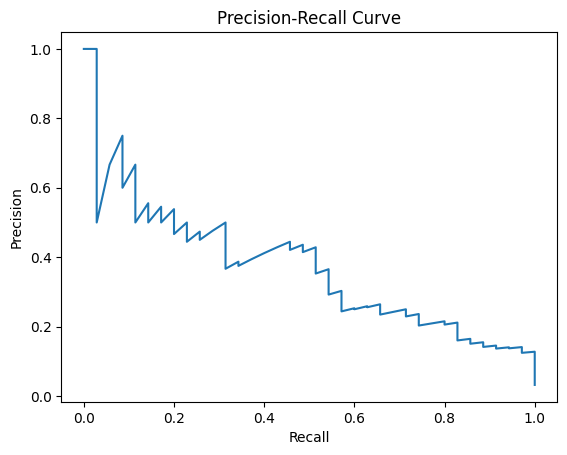

In [208]:
import matplotlib.pyplot as plt

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [203]:
f1 = 2 * precision * recall / (precision + recall + 1e-8)
best_idx = np.argmax(f1)
best_th = thresholds[best_idx]

In [204]:
best_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'auc'


In [205]:
y_test_prob = best_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= best_th).astype(int)

In [210]:
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

print(classification_report(y_test, y_test_pred))
f1 = f1_score(y_test, y_test_pred)
print("F1 score:", f1)

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1320
           1       0.46      0.59      0.51        44

    accuracy                           0.96      1364
   macro avg       0.72      0.78      0.75      1364
weighted avg       0.97      0.96      0.97      1364

F1 score: 0.5148514851485149
